In [4]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

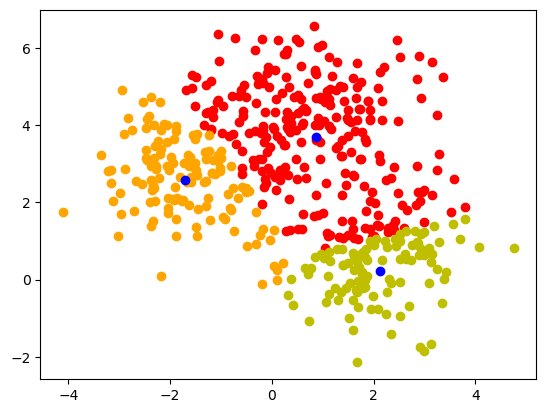

In [ ]:
### Implement k-Means Clustering ###
k = 3
n_feat = 2

# Begin by creating a dataset
from sklearn.datasets import make_blobs
X_data, y = make_blobs(n_samples = 500, n_features = n_feat, centers = k, random_state = 0)
#plt.scatter(X_data[:, 0], X_data[:, 1])

# Implement k-means clustering
def distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def assign_clusters(X, centers):
    dX = X - centers[:, np.newaxis, :]
    dist = np.sqrt((dX**2).sum(axis = 2))
    assignment = np.argmin(dist, axis = 0)
    # assigned_clusters has shape (k, n_samples, n_feat)
    assigned_clusters = [X[assignment == i, :] for i in range(k)]
    return assigned_clusters

def update_centers(assigned_clusters):
    center_list = [np.mean(assigned_clusters[i], axis = 0) for i in range(k)]
    return np.array(center_list)

np.random.seed(0)
centers = np.random.rand(k, n_feat)

assigned_clusters = assign_clusters(X_data, centers)
centers = update_centers(assigned_clusters)

# Plot the results
cs = ['r', 'y', 'orange', 'b']
for i in range(k):
    plt.scatter(assigned_clusters[i][:, 0], assigned_clusters[i][:, 1], c = cs[i])
    plt.scatter(centers[i, 0], centers[i, 1], c = cs[k])
plt.show()

